# Section 7.1 Timing Visualizations

This notebook is designed for `exp1` through `exp4` in Section 7.1.

Before running this notebook, generate timing breakdown CSV files with:

- `python experiments/reference_1_section7_1/exp1_live.py --detailed-timing`
- `python experiments/reference_1_section7_1/exp2_live.py --detailed-timing`
- `python experiments/reference_1_section7_1/exp3_live.py --detailed-timing`
- `python experiments/reference_1_section7_1/exp4_live.py --detailed-timing`

Notebook structure:

1. Shared setup and helper cells
2. One dedicated execution cell for `exp1`
3. One dedicated execution cell for `exp2`
4. One dedicated execution cell for `exp3`
5. One dedicated execution cell for `exp4`

For each experiment, this notebook renders 19 plots:

- Three total-runtime plots for `Non-random`, `Random Sampling`, and `Random Projection`
- Two detailed plots for `Non-random`
- Six detailed plots for `Random Sampling`
- Eight detailed plots for `Random Projection`

All plot scales are unified by metric across `exp1` through `exp4`. For example, every `time_sec` plot shares the same y-axis range, every `nr_eig_sec` plot shares the same y-axis range, and so on.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent
EXPERIMENTS_ROOT = PROJECT_ROOT / "experiments"
NOTEBOOK_OUTPUT_ROOT = EXPERIMENTS_ROOT / "timing_visualizations"

METHOD_ORDER = ["Non-random", "Random Sampling", "Random Projection"]
METHOD_COLORS = {
    "Non-random": "#2ca02c",
    "Random Sampling": "#ff7f0e",
    "Random Projection": "#1f77b4",
}

METRIC_LABELS = {
    "time_sec": "Total runtime (sec)",
    "nr_eig_sec": "Top eigenvectors on A (sec)",
    "nr_kmeans_sec": "K-means on eigenvector rows (sec)",
    "rs_sample_mask_sec": "Bernoulli mask generation (sec)",
    "rs_build_sampled_matrix_sec": "Build sampled matrix A_s (sec)",
    "rs_eig_sec": "Top eigenpairs on A_s (sec)",
    "rs_reconstruct_sec": "Rank-K' reconstruction (sec)",
    "rs_symmetrize_sec": "Symmetrization (sec)",
    "rs_kmeans_sec": "K-means on eigenvector rows (sec)",
    "rp_draw_omega_sec": "Draw Gaussian Omega (sec)",
    "rp_power_iter_sec": "Power iteration (sec)",
    "rp_qr_sec": "QR factorization (sec)",
    "rp_build_core_sec": "Build core matrix C (sec)",
    "rp_reconstruct_sec": "Reconstruct A_hat (sec)",
    "rp_small_eig_sec": "Top eigenvectors on C (sec)",
    "rp_lift_sec": "Lift U_rp = Q Uc (sec)",
    "rp_kmeans_sec": "K-means on U_rp rows (sec)",
}

METHOD_STEP_METRICS = {
    "Non-random": [
        "nr_eig_sec",
        "nr_kmeans_sec",
    ],
    "Random Sampling": [
        "rs_sample_mask_sec",
        "rs_build_sampled_matrix_sec",
        "rs_eig_sec",
        "rs_reconstruct_sec",
        "rs_symmetrize_sec",
        "rs_kmeans_sec",
    ],
    "Random Projection": [
        "rp_draw_omega_sec",
        "rp_power_iter_sec",
        "rp_qr_sec",
        "rp_build_core_sec",
        "rp_reconstruct_sec",
        "rp_small_eig_sec",
        "rp_lift_sec",
        "rp_kmeans_sec",
    ],
}

EXPERIMENT_CONFIG = {
    "exp1": {
        "label": "Exp1 (n variation)",
        "summary_filename": "exp1_timing_breakdown_summary.csv",
        "display_cols": ["n"],
        "x_col": "n",
        "x_label": "n",
    },
    "exp2": {
        "label": "Exp2 (alpha_n variation)",
        "summary_filename": "exp2_timing_breakdown_summary.csv",
        "display_cols": ["alpha_n"],
        "x_col": "alpha_n",
        "x_label": "alpha_n",
    },
    "exp3": {
        "label": "Exp3 (K variation)",
        "summary_filename": "exp3_timing_breakdown_summary.csv",
        "display_cols": ["K"],
        "x_col": "K",
        "x_label": "K",
    },
    "exp4": {
        "label": "Exp4 (n variation, alpha_n = 2/sqrt(n))",
        "summary_filename": "exp4_timing_breakdown_summary.csv",
        "display_cols": ["n", "alpha_n"],
        "x_col": "n",
        "x_label": "n",
    },
}

EXPECTED_PLOT_COUNT_PER_EXPERIMENT = 19
ALL_TIMING_METRICS = ["time_sec"]
for method_name in METHOD_ORDER:
    ALL_TIMING_METRICS.extend(METHOD_STEP_METRICS[method_name])


In [2]:
def find_latest_summary(summary_filename):
    matches = list(EXPERIMENTS_ROOT.glob(f"**/{summary_filename}"))
    if not matches:
        return None
    return max(matches, key=lambda path: path.stat().st_mtime)


def method_slug(method_name):
    return method_name.lower().replace("-", "").replace(" ", "_")


def metric_title(method_name, metric_name):
    return f"{method_name} - {METRIC_LABELS.get(metric_name, metric_name)}"


def build_timing_table(df, base_cols, metrics):
    cols = []
    for col in base_cols:
        if col in df.columns and col not in cols:
            cols.append(col)
    for metric in metrics:
        mean_col = f"{metric}_mean"
        std_col = f"{metric}_std"
        if mean_col in df.columns and mean_col not in cols:
            cols.append(mean_col)
        if std_col in df.columns and std_col not in cols:
            cols.append(std_col)
    table = df.loc[:, cols].copy()
    sort_cols = [col for col in base_cols if col in table.columns]
    if sort_cols:
        table = table.sort_values(sort_cols)
    return table.reset_index(drop=True)


def load_all_summaries():
    loaded = {}
    for exp_key, cfg in EXPERIMENT_CONFIG.items():
        summary_path = find_latest_summary(cfg["summary_filename"])
        if summary_path is None:
            loaded[exp_key] = {"path": None, "df": None}
        else:
            loaded[exp_key] = {"path": summary_path, "df": pd.read_csv(summary_path)}
    return loaded


def compute_global_metric_limits(loaded_summaries):
    limits = {}
    for metric_name in ALL_TIMING_METRICS:
        max_value = 0.0
        mean_col = f"{metric_name}_mean"
        std_col = f"{metric_name}_std"
        for item in loaded_summaries.values():
            df = item["df"]
            if df is None or mean_col not in df.columns:
                continue
            upper = df[mean_col].astype(float)
            if std_col in df.columns:
                upper = upper + df[std_col].astype(float)
            if not upper.empty:
                max_value = max(max_value, float(upper.max()))
        padding = 0.05 * max_value if max_value > 0 else 1.0
        limits[metric_name] = (0.0, max_value + padding)
    return limits


def plot_metric(df, method_name, x_col, x_label, metric_name, exp_label, output_dir, global_limits):
    mean_col = f"{metric_name}_mean"
    std_col = f"{metric_name}_std"
    if mean_col not in df.columns:
        print(f"Skipping {exp_label} / {method_name} / {metric_name}: missing column {mean_col}")
        return None

    method_df = df[df["method"] == method_name].copy()
    if method_df.empty:
        print(f"Skipping {exp_label} / {method_name} / {metric_name}: no rows found")
        return None

    method_df = method_df.sort_values(x_col)
    fig, ax = plt.subplots(figsize=(8.0, 4.8))
    color = METHOD_COLORS[method_name]
    ax.plot(
        method_df[x_col],
        method_df[mean_col],
        color=color,
        linewidth=2.2,
        marker="o",
    )
    if std_col in method_df.columns:
        lower = method_df[mean_col] - method_df[std_col]
        upper = method_df[mean_col] + method_df[std_col]
        ax.fill_between(method_df[x_col], lower, upper, color=color, alpha=0.2)
    if metric_name in global_limits:
        ax.set_ylim(*global_limits[metric_name])
    ax.set_title(f"{exp_label} | {metric_title(method_name, metric_name)}")
    ax.set_xlabel(x_label)
    ax.set_ylabel(METRIC_LABELS.get(metric_name, metric_name))
    ax.grid(alpha=0.3)
    fig.tight_layout()

    out_png = output_dir / f"{method_slug(method_name)}_{metric_name}.png"
    fig.savefig(out_png, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return out_png


def render_experiment(exp_key, cfg, loaded_summaries, global_limits):
    display(Markdown(f"## {cfg['label']}"))
    item = loaded_summaries[exp_key]
    summary_path = item["path"]
    df = item["df"]

    if summary_path is None or df is None:
        print(
            "Timing summary CSV not found. "
            f"Expected filename: {cfg['summary_filename']}. "
            "Run the matching experiment with --detailed-timing first."
        )
        return

    print(f"Loaded summary CSV: {summary_path}")
    output_dir = NOTEBOOK_OUTPUT_ROOT / exp_key
    output_dir.mkdir(parents=True, exist_ok=True)
    print(f"Output directory: {output_dir}")

    display(Markdown("### Timing Tables"))
    overall_table = build_timing_table(df, cfg["display_cols"] + ["method"], ["time_sec"])
    display(Markdown("#### Overall runtime summary"))
    display(overall_table.round(6))

    for method_name in METHOD_ORDER:
        method_df = df[df["method"] == method_name].copy()
        detail_metrics = METHOD_STEP_METRICS[method_name]
        detail_table = build_timing_table(method_df, cfg["display_cols"], detail_metrics)
        display(Markdown(f"#### {method_name} detailed timing summary"))
        display(detail_table.round(6))

    display(Markdown("### Plots"))
    created_paths = []

    for method_name in METHOD_ORDER:
        out_path = plot_metric(
            df=df,
            method_name=method_name,
            x_col=cfg["x_col"],
            x_label=cfg["x_label"],
            metric_name="time_sec",
            exp_label=cfg["label"],
            output_dir=output_dir,
            global_limits=global_limits,
        )
        if out_path is not None:
            created_paths.append(out_path)

    for method_name in METHOD_ORDER:
        for metric_name in METHOD_STEP_METRICS[method_name]:
            out_path = plot_metric(
                df=df,
                method_name=method_name,
                x_col=cfg["x_col"],
                x_label=cfg["x_label"],
                metric_name=metric_name,
                exp_label=cfg["label"],
                output_dir=output_dir,
                global_limits=global_limits,
            )
            if out_path is not None:
                created_paths.append(out_path)

    print(
        f"Prepared {len(created_paths)} plot outputs for {exp_key}. "
        f"Expected: {EXPECTED_PLOT_COUNT_PER_EXPERIMENT}."
    )
    for path in created_paths:
        print(f"  - {path}")


In [3]:
LOADED_SUMMARIES = load_all_summaries()
GLOBAL_METRIC_LIMITS = compute_global_metric_limits(LOADED_SUMMARIES)

display(Markdown("## Global Y-Axis Limits"))
global_limits_table = pd.DataFrame(
    [
        {
            "metric": metric_name,
            "y_min": y_range[0],
            "y_max": y_range[1],
        }
        for metric_name, y_range in GLOBAL_METRIC_LIMITS.items()
    ]
)
display(global_limits_table.round(6))


## Global Y-Axis Limits

,metric,y_min,y_max
0,time_sec,0.0,0.758061
1,nr_eig_sec,0.0,0.719314
2,nr_kmeans_sec,0.0,0.039290
3,rs_sample_mask_sec,0.0,0.006862
4,rs_build_sampled_matrix_sec,0.0,0.018081
5,rs_eig_sec,0.0,0.009993
6,rs_reconstruct_sec,0.0,0.014128
7,rs_symmetrize_sec,0.0,0.006784
8,rs_kmeans_sec,0.0,0.044834
9,rp_draw_omega_sec,0.0,0.000163


## Exp1 (n variation)

Loaded summary CSV: C:\Users\WWindows10\Documents\github_project\python-rand-nla-research\experiments\section7_1\results\exp1_paper_aligned_live\exp1_timing_breakdown_summary.csv
Output directory: C:\Users\WWindows10\Documents\github_project\python-rand-nla-research\experiments\timing_visualizations\exp1


### Timing Tables

#### Overall runtime summary

,n,method,time_sec_mean,time_sec_std
0,200,Non-random,0.025653,0.000847
1,200,Random Projection,0.092057,0.305112
2,200,Random Sampling,0.025867,0.001474
3,400,Non-random,0.122267,0.020112
4,400,Random Projection,0.028481,0.002001
5,400,Random Sampling,0.034808,0.001443
6,600,Non-random,0.154896,0.072471
7,600,Random Projection,0.083282,0.020516
8,600,Random Sampling,0.043709,0.002111
9,800,Non-random,0.443695,0.278267


...

#### Random Sampling detailed timing summary

,n,rs_sample_mask_sec_mean,rs_sample_mask_sec_std,rs_build_sampled_matrix_sec_mean,rs_build_sampled_matrix_sec_std,rs_eig_sec_mean,rs_eig_sec_std,rs_reconstruct_sec_mean,rs_reconstruct_sec_std,rs_symmetrize_sec_mean,rs_symmetrize_sec_std,rs_kmeans_sec_mean,rs_kmeans_sec_std
0,200,0.000213,0.000018,0.000306,0.000024,0.002857,0.000367,0.000040,0.000006,0.000072,0.000019,0.022375,0.001394
1,400,0.000636,0.000139,0.001829,0.000199,0.003599,0.000426,0.000327,0.000046,0.000844,0.000145,0.027570,0.001526
2,600,0.002292,0.000260,0.004837,0.000508,0.004435,0.000577,0.000508,0.000057,0.002213,0.000409,0.029419,0.001392
3,800,0.004166,0.000513,0.009788,0.000987,0.008442,0.001075,0.001527,0.001057,0.004544,0.000769,0.033831,0.003165
4,1000,0.004474,0.000844,0.012611,0.004609,0.006819,0.001039,0.006219,0.007237,0.004350,0.001086,0.032798,0.002388
5,1200,0.005961,0.000574,0.015186,0.000493,0.007142,0.000337,0.000894,0.000155,0.006155,0.000306,0.040052,0.002647


#### Random Projection detailed timing summary

,n,rp_draw_omega_sec_mean,rp_draw_omega_sec_std,rp_power_iter_sec_mean,rp_power_iter_sec_std,rp_qr_sec_mean,rp_qr_sec_std,rp_build_core_sec_mean,rp_build_core_sec_std,rp_reconstruct_sec_mean,rp_reconstruct_sec_std,rp_small_eig_sec_mean,rp_small_eig_sec_std,rp_lift_sec_mean,rp_lift_sec_std,rp_kmeans_sec_mean,rp_kmeans_sec_std
0,200,0.000026,0.000002,0.000209,0.000030,0.000078,0.000020,0.000054,0.000011,0.000042,0.000006,0.000064,0.000018,0.000006,0.000001,0.091574,0.305078
1,400,0.000047,0.000004,0.000430,0.000049,0.000104,0.000014,0.000171,0.000227,0.000608,0.000841,0.000079,0.000014,0.000009,0.000002,0.027029,0.001561
2,600,0.000069,0.000008,0.000828,0.000084,0.000142,0.000018,0.053224,0.021580,0.000527,0.000066,0.000119,0.000026,0.000012,0.000003,0.028356,0.001701
3,800,0.000110,0.000028,0.001572,0.000270,0.000278,0.000049,0.052940,0.052085,0.000960,0.000256,0.000130,0.000029,0.000017,0.000010,0.034577,0.004478
4,1000,0.000114,0.000009,0.001921,0.000213,0.000315,0.000030,0.018182,0.037279,0.000831,0.000275,0.000108,0.000037,0.000015,0.000003,0.031380,0.003222
5,1200,0.000144,0.000011,0.002647,0.000489,0.000374,0.000047,0.012586,0.030044,0.000921,0.000157,0.000116,0.000037,0.000019,0.000005,0.034631,0.003137


### Plots

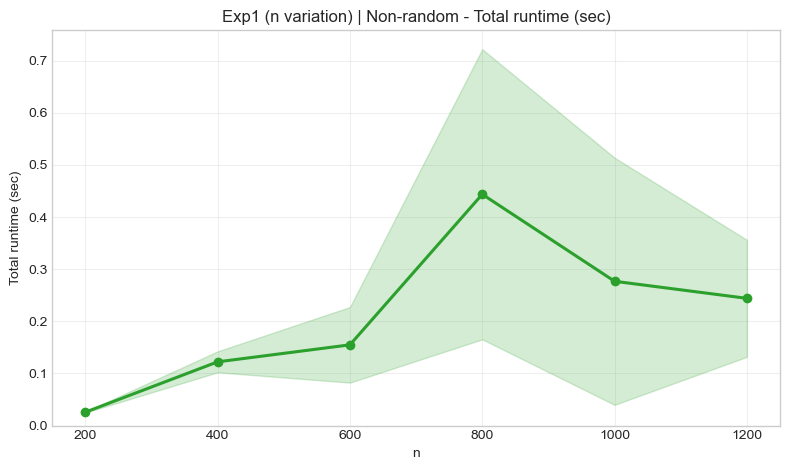

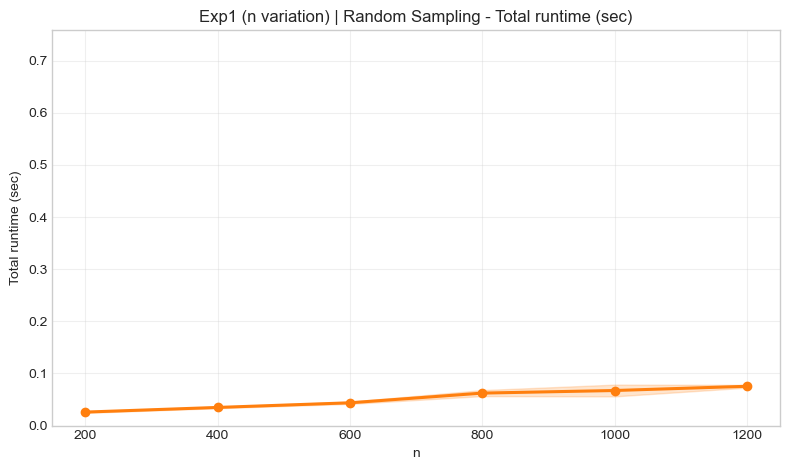

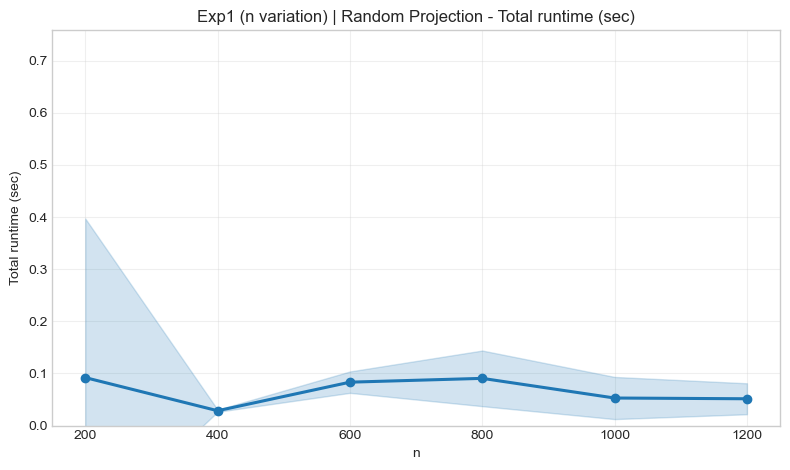

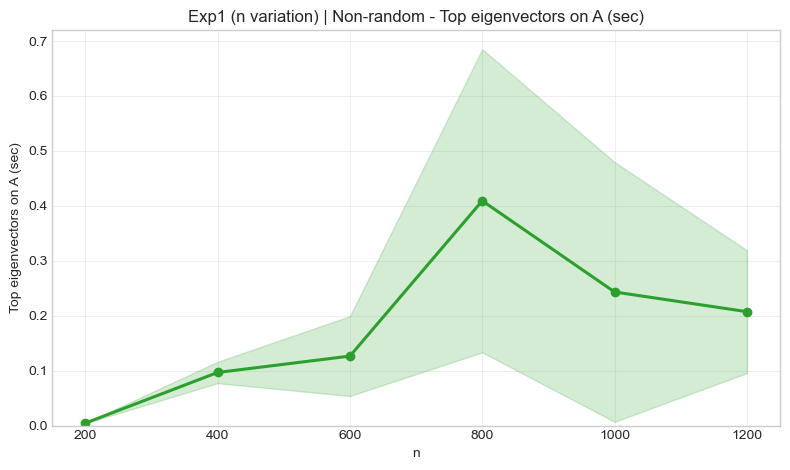

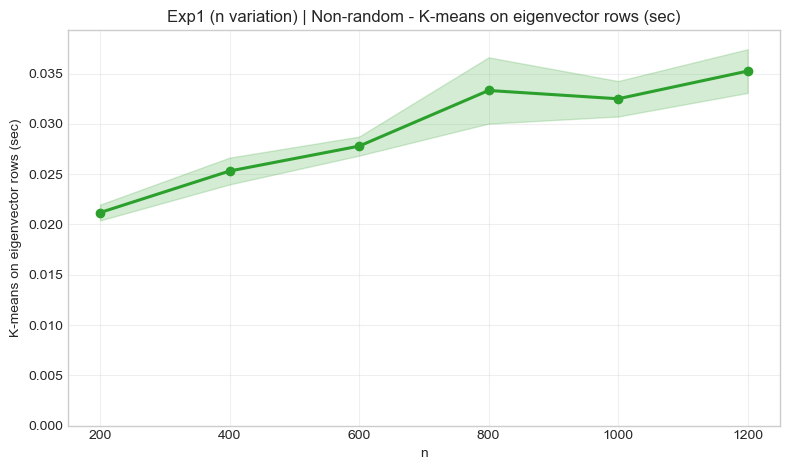

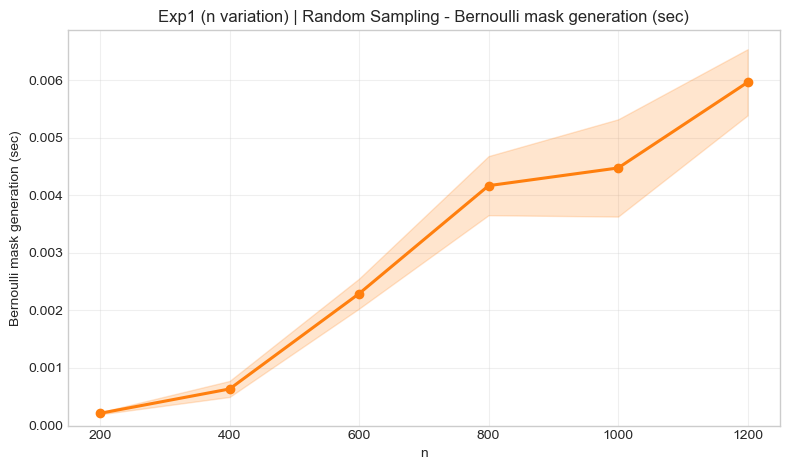

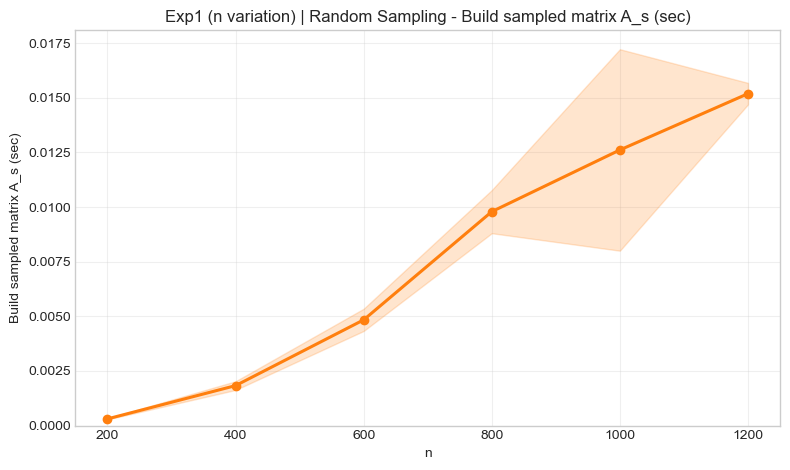

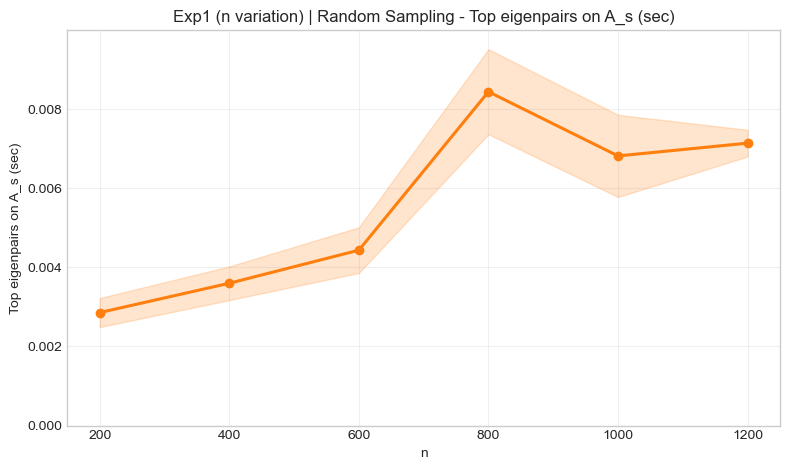

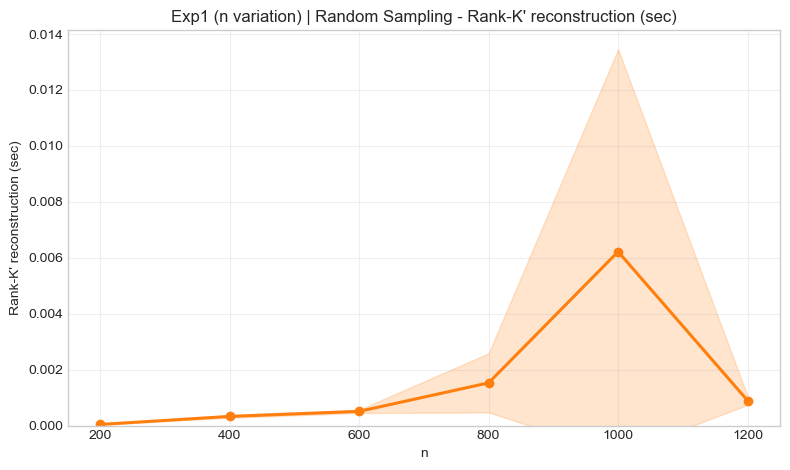

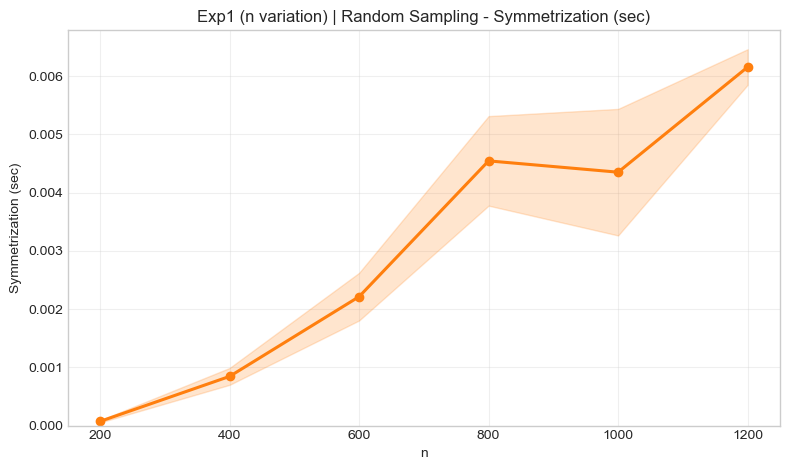

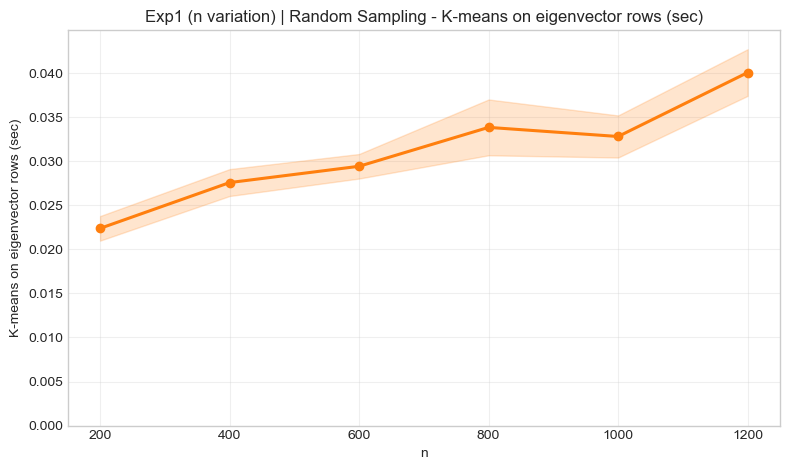

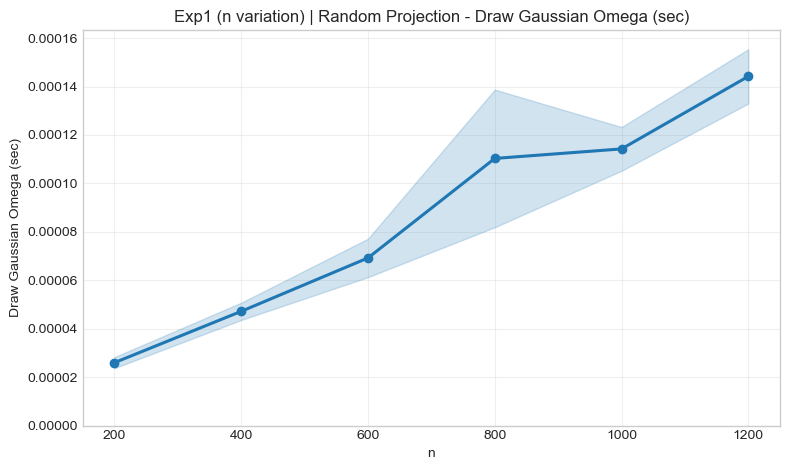

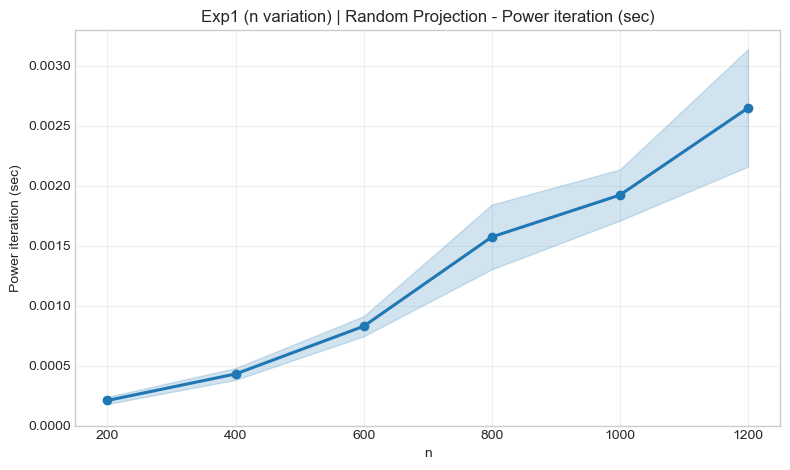

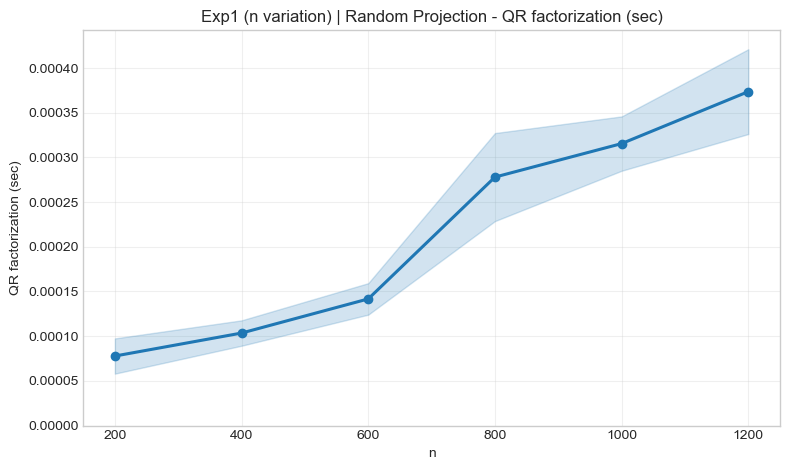

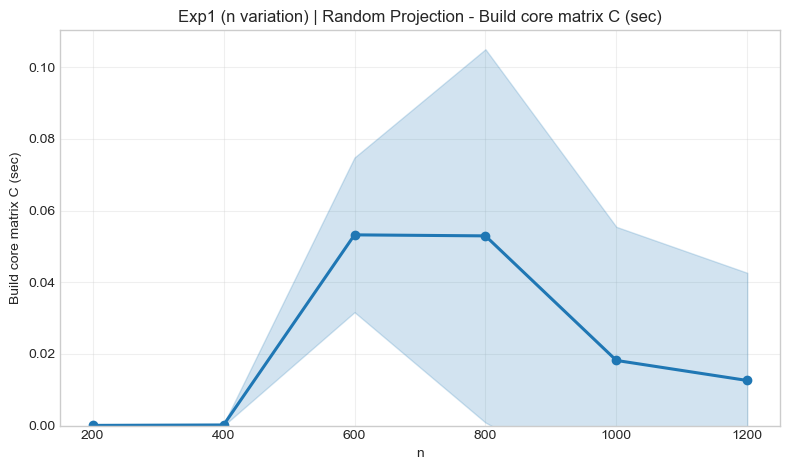

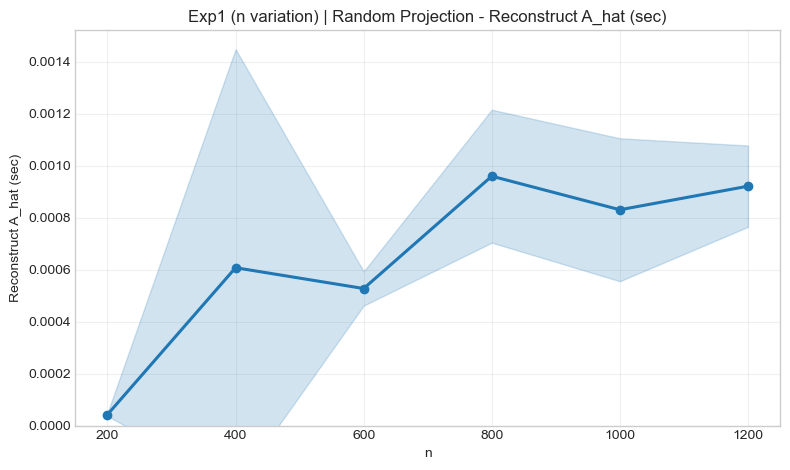

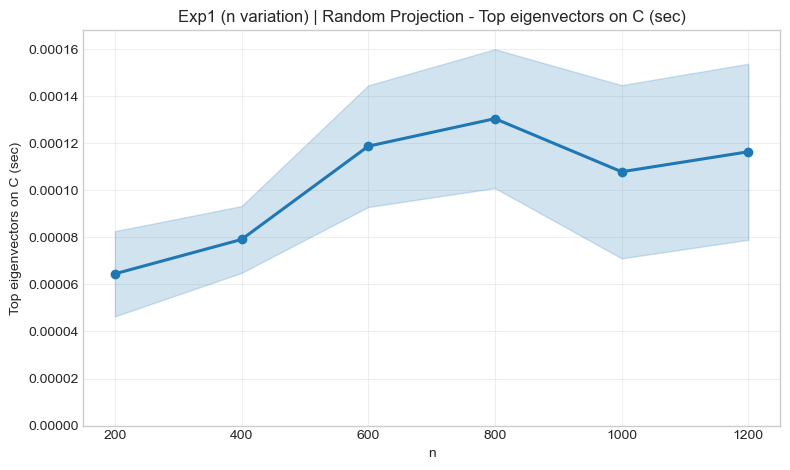

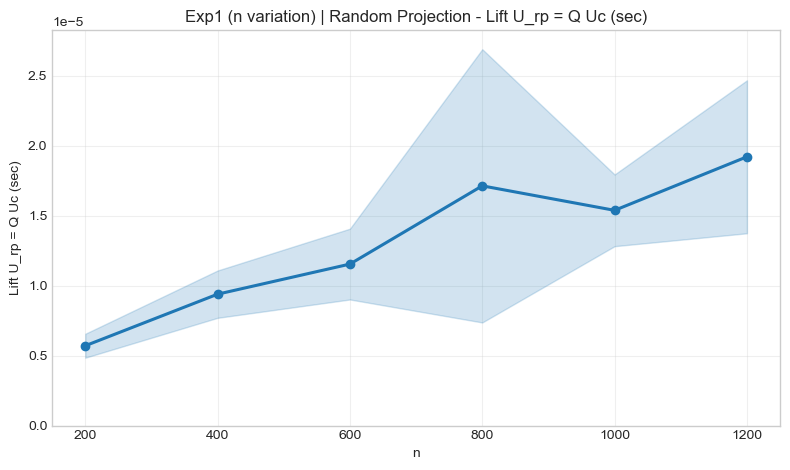

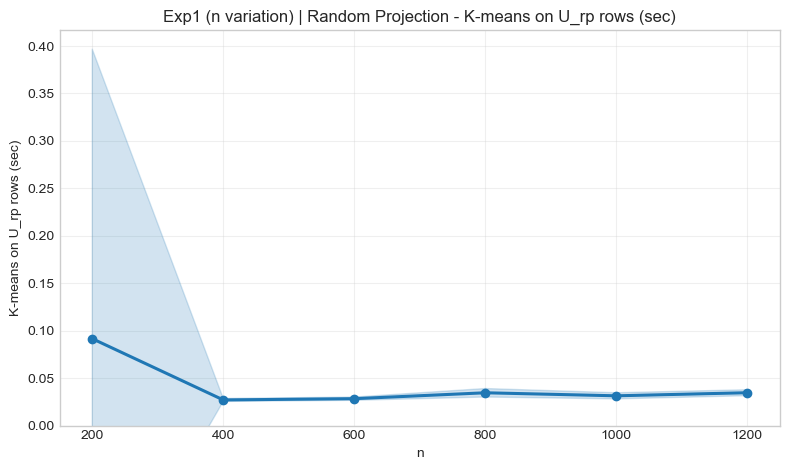

Prepared 19 plot outputs for exp1. Expected: 19.
  - C:\Users\WWindows10\Documents\github_project\python-rand-nla-research\experiments\timing_visualizations\exp1\nonrandom_time_sec.png
  - C:\Users\WWindows10\Documents\github_project\python-rand-nla-research\experiments\timing_visualizations\exp1\random_sampling_time_sec.png
  - C:\Users\WWindows10\Documents\github_project\python-rand-nla-research\experiments\timing_visualizations\exp1\random_projection_time_sec.png
  - C:\Users\WWindows10\Documents\github_project\python-rand-nla-research\experiments\timing_visualizations\exp1\nonrandom_nr_eig_sec.png
  - C:\Users\WWindows10\Documents\github_project\python-rand-nla-research\experiments\timing_visualizations\exp1\nonrandom_nr_kmeans_sec.png
  - C:\Users\WWindows10\Documents\github_project\python-rand-nla-research\experiments\timing_visualizations\exp1\random_sampling_rs_sample_mask_sec.png
  - C:\Users\WWindows10\Documents\github_project\python-rand-nla-research\experiments\timing_visua

In [4]:
render_experiment("exp1", EXPERIMENT_CONFIG["exp1"], LOADED_SUMMARIES, GLOBAL_METRIC_LIMITS)


In [5]:
render_experiment("exp2", EXPERIMENT_CONFIG["exp2"], LOADED_SUMMARIES, GLOBAL_METRIC_LIMITS)


## Exp2 (alpha_n variation)

Timing summary CSV not found. Expected filename: exp2_timing_breakdown_summary.csv. Run the matching experiment with --detailed-timing first.


In [6]:
render_experiment("exp3", EXPERIMENT_CONFIG["exp3"], LOADED_SUMMARIES, GLOBAL_METRIC_LIMITS)


## Exp3 (K variation)

Timing summary CSV not found. Expected filename: exp3_timing_breakdown_summary.csv. Run the matching experiment with --detailed-timing first.


In [7]:
render_experiment("exp4", EXPERIMENT_CONFIG["exp4"], LOADED_SUMMARIES, GLOBAL_METRIC_LIMITS)


## Exp4 (n variation, alpha_n = 2/sqrt(n))

Timing summary CSV not found. Expected filename: exp4_timing_breakdown_summary.csv. Run the matching experiment with --detailed-timing first.
